Using: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


Epoch [1/1] Batch [0/79] Loss D: 1.6184 Loss G: 6.8796


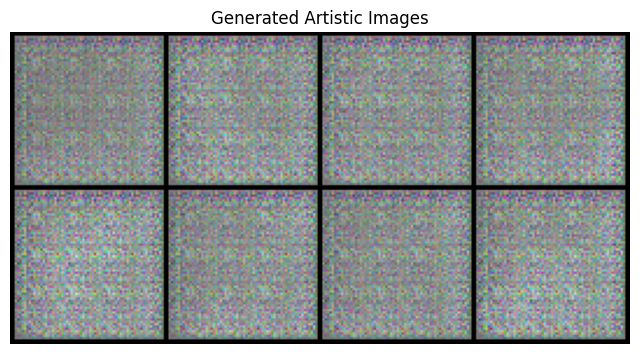

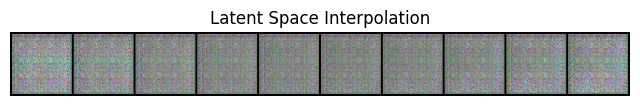

In [2]:
# ============================
# GAN LAB 8 - FULL ONE-CELL CODE FOR COLAB
# DCGAN on CIFAR-10 + image generation + latent interpolation
# ============================

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

# ----------------------------
# 1) Reproducibility
# ----------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# ----------------------------
# 2) Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ----------------------------
# 3) Hyperparameters
# ----------------------------
image_size = 64
batch_size = 128
latent_dim = 100
num_epochs = 1          # increase to 5 or more for better results
lr = 0.0002
beta1 = 0.5
ngf = 64
ndf = 64
num_workers = 2

# ----------------------------
# 4) Dataset
# ----------------------------
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Optional: use a smaller subset for faster training in Colab
subset_size = 10000
indices = torch.randperm(len(train_dataset))[:subset_size]
train_subset = torch.utils.data.Subset(train_dataset, indices)

train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

# ----------------------------
# 5) DCGAN Models
# ----------------------------
class Generator(nn.Module):
    def __init__(self, latent_dim, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            # input: (latent_dim) x 1 x 1
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)

# ----------------------------
# 6) Initialize
# ----------------------------
G = Generator(latent_dim, ngf).to(device)
D = Discriminator(ndf).to(device)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)

# ----------------------------
# 7) Loss and Optimizers
# ----------------------------
criterion = nn.BCELoss()
optimizerD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))

# ----------------------------
# 8) Helpers
# ----------------------------
def denormalize(x):
    return (x + 1) / 2

def show_images(images, title, nrow=4):
    grid = make_grid(denormalize(images), nrow=nrow)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(title)
    plt.show()

fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

# ----------------------------
# 9) Train DCGAN
# ----------------------------
G.train()
D.train()

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        real_labels = torch.ones(b_size, device=device)
        fake_labels = torch.zeros(b_size, device=device)

        # --------------------
        # Train Discriminator
        # --------------------
        D.zero_grad()

        output_real = D(real_images)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_images = G(noise)
        output_fake = D(fake_images.detach())
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        # --------------------
        # Train Generator
        # --------------------
        G.zero_grad()
        output_fake_for_G = D(fake_images)
        loss_G = criterion(output_fake_for_G, real_labels)
        loss_G.backward()
        optimizerG.step()

        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{i}/{len(train_loader)}] "
                  f"Loss D: {loss_D.item():.4f} Loss G: {loss_G.item():.4f}")

# ----------------------------
# 10) Generate Artistic Images
# ----------------------------
G.eval()
with torch.no_grad():
    sample_noise = torch.randn(8, latent_dim, 1, 1, device=device)
    generated = G(sample_noise).cpu()

show_images(generated, "Generated Artistic Images", nrow=4)

# ----------------------------
# 11) Latent Space Interpolation
# ----------------------------
def interpolate(z1, z2, steps=10):
    # z1, z2 shape: (1, latent_dim, 1, 1)
    vals = []
    for alpha in np.linspace(0, 1, steps):
        z = (1 - alpha) * z1 + alpha * z2
        vals.append(z.squeeze(0))  # make each item shape (latent_dim,1,1)
    return torch.stack(vals, dim=0)  # (steps, latent_dim, 1, 1)

z1 = torch.randn(1, latent_dim, 1, 1, device=device)
z2 = torch.randn(1, latent_dim, 1, 1, device=device)
z_interp = interpolate(z1, z2, steps=10).to(device)

with torch.no_grad():
    interp_images = G(z_interp).cpu()

show_images(interp_images, "Latent Space Interpolation", nrow=10)